## Working with DGGAL in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/05_dggal.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/05_dggal.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/05_dggal.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://jupyterlite.gishub.vn/lab/index.html?path=notebooks/vgrid/05_dggal.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgrid
Uncomment the following line to install [vgrid](https://pypi.org/project/vgrid/).

In [1]:
# %pip install vgrid --upgrade

### latlon2dggal

In [1]:
from vgrid.conversion.latlon2dggs import latlon2dggal

dggs_type = "healpix"  # choose one from ['gnosis','isea4r','isea9r','isea3h','isea7h','isea7h_z7',
# 'ivea4r','ivea9r','ivea3h','ivea7h','ivea7h_z7','rtea4r','rtea9r','rtea3h','rtea7h','rtea7h_z7','healpix','rhealpix']
resolution = 10
dggal_id = latlon2dggal(dggs_type, 10.775276, 106.706797, resolution)
dggal_id

'K7-8BF4D'

### DGGAL to Polygon

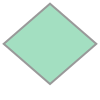

In [2]:
from vgrid.conversion.dggs2geo.dggal2geo import dggal2geo

dggal_geo = dggal2geo(dggs_type, dggal_id, split_antimeridian=False)
dggal_geo

### DGGAL to GeoJSON

In [ ]:
from vgrid.conversion.dggs2geo.dggal2geo import dggal2geojson

dggal_geojson = dggal2geojson(dggs_type, dggal_id, split_antimeridian=False)
# dggal_geojson

### Vector to DGGAL

#### Multi(Point) to DGGAL

Processing features: 100%|██████████| 12/12 [00:00<00:00, 794.79it/s]


<Axes: >

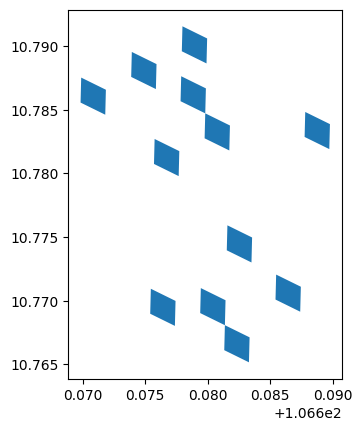

In [10]:
from vgrid.conversion.vector2dggs.vector2dggal import vector2dggal
import geopandas as gpd

dggs_type = "ivea4r"
file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/point.geojson"
)

gdf = gpd.read_file(file_path)

point_to_dggal = vector2dggal(
    dggs_type=dggs_type,
    vector_data=file_path,
    # resolution = 15,
    topology=True,
    output_format="gpd",
)
point_to_dggal.plot()

#### Multi(Polyline) to DGGAL

#### Multi(Polygon) to DGGAL

Processing features: 100%|██████████| 7/7 [00:00<00:00,  8.29it/s]


<Axes: >

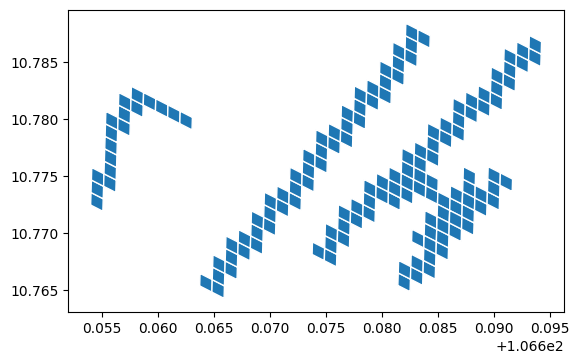

In [3]:
from vgrid.conversion.vector2dggs.vector2dggal import vector2dggal

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polyline.geojson"
dggs_type = "isea9r"  # choose one from ['gnosis','isea4r','isea9r','isea3h','isea7h','isea7h_z7',
# 'ivea4r','ivea9r','ivea3h','ivea7h','ivea7h_z7','rtea4r','rtea9r','rtea3h','rtea7h','rtea7h_z7','healpix','rhealpix']
resolution = 10
vector_to_dggal = vector2dggal(
    dggs_type=dggs_type,
    vector_data=file_path,
    resolution=resolution,
    compact=False,
    split_antimeridian=False,
    output_format="gpd",
)
# Visualize the output
vector_to_dggal.plot(edgecolor="white")

Processing features: 100%|██████████| 1/1 [00:00<00:00,  9.58it/s]


<Axes: >

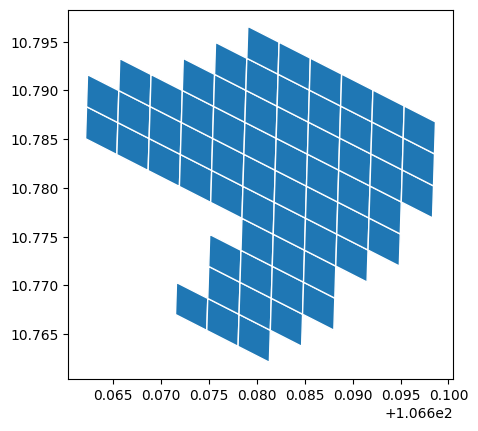

In [5]:
from vgrid.conversion.vector2dggs.vector2dggal import vector2dggal

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon2.geojson"
dggs_type = "isea9r"  # choose one from ['gnosis','isea4r','isea9r','isea3h','isea7h','isea7h_z7',
# 'ivea4r','ivea9r','ivea3h','ivea7h','ivea7h_z7','rtea4r','rtea9r','rtea3h','rtea7h','rtea7h_z7','healpix','rhealpix']
resolution = 9
vector_to_dggal = vector2dggal(
    dggs_type=dggs_type,
    vector_data=file_path,
    resolution=resolution,
    compact=False,
    predicate="intersects",
    split_antimeridian=False,
    output_format="gpd",
)
# Visualize the output
vector_to_dggal.plot(edgecolor="white")

### DGGAL Compact

<Axes: >

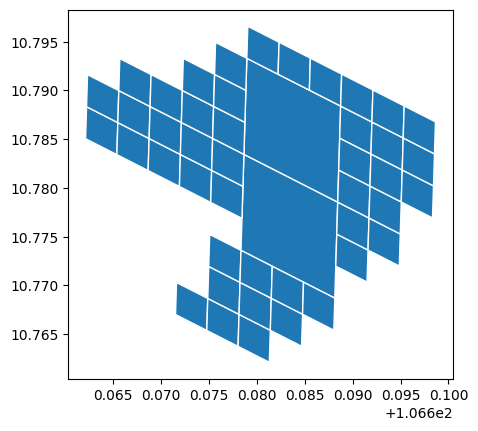

In [6]:
from vgrid.conversion.dggscompact.dggalcompact import dggalcompact

dggal_compacted = dggalcompact(
    dggs_type, vector_to_dggal, split_antimeridian=False, output_format="gpd"
)
dggal_compacted.plot(edgecolor="white")

### DGGAL Expand

<Axes: >

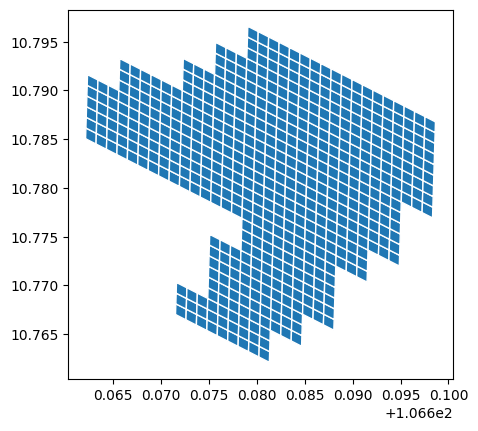

In [7]:
from vgrid.conversion.dggscompact.dggalcompact import dggalexpand

dggal_expanded = dggalexpand(
    dggs_type,
    vector_to_dggal,
    resolution=10,
    split_antimeridian=False,
    output_format="gpd",
)
# dggal_expanded
dggal_expanded.plot(edgecolor="white")

### DGGAL Binning

Generating ISEA9R DGGS: 100%|██████████| 1165/1165 [00:01<00:00, 988.29it/s]


<Axes: >

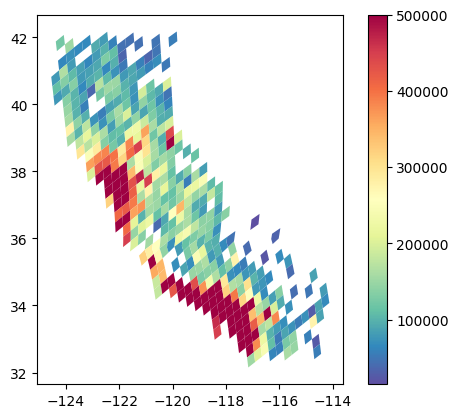

In [9]:
from vgrid.binning.dggalbin import dggalbin

dggs_type = "isea9r"  # choose one from ['gnosis','isea4r','isea9r','isea3h','isea7h','isea7h_z7',
# 'ivea4r','ivea9r','ivea3h','ivea7h','ivea7h_z7','rtea4r','rtea9r','rtea3h','rtea7h','rtea7h_z7','healpix','rhealpix']
file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv"
)
stats = "max"
numeric_col = "median_house_value"

dggal_bin = dggalbin(
    dggs_type,
    file_path,
    resolution=5,
    stats=stats,
    numeric_col=numeric_col,
    # category_col="category",
    split_antimeridian=False,
    output_format="gpd",
)
# dggal_bin.head()
dggal_bin.plot(
    column=f"{numeric_col}_{stats}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### DGGAL Resampling

Generating A5 cells: 100%|██████████| 2100/2100 [00:00<00:00, 7776.85 cells/s]


<Axes: >

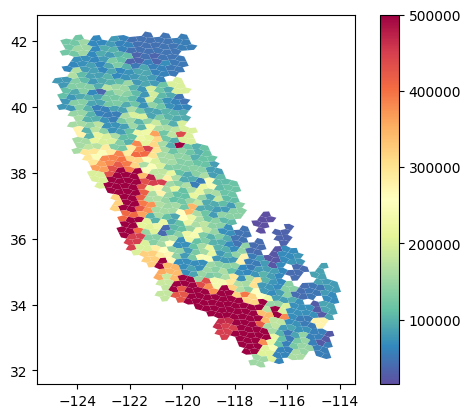

In [3]:
from vgrid.conversion.dggsresample import dggsresample

dggal_resample = dggsresample(
    source_dggs=dggal_bin,
    dggs_from=f"dggal_{dggs_type}",
    dggs_to="a5",
    method="nearest",  # area_weighted, nearest
    dggs_col=f"dggal_{dggs_type}",
    resample_col=f"{numeric_col}_{stats}",  # column on h3_bin with numbers
    fix_antimeridian=None,
    split_antimeridian=False,
)
dggal_resample.plot(
    column=f"{numeric_col}_{stats}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Raster to DGGAL

#### Download and open raster

In [ ]:
from vgrid.utils.io import download_file
import rasterio
from rasterio.plot import show

raster_url = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/raster/rgb.tif"
)
raster_file = download_file(raster_url)
src = rasterio.open(raster_file, "r")
print(src.meta)
show(src)

#### Convert raster to DGGAL

In [11]:
# %pip install folium

In [ ]:
from vgrid.conversion.raster2dggs.raster2dggal import raster2dggal

dggs_type = "healpix"  # choose one from ['gnosis','isea4r','isea9r','isea3h','isea7h','isea7h_z7',
# 'ivea4r','ivea9r','ivea3h','ivea7h','ivea7h_z7','rtea4r','rtea9r','rtea3h','rtea7h','rtea7h_z7','healpix','rhealpix']
raster_to_dggal = raster2dggal(
    dggs_type,
    raster_file,
    resolution=23,
    method="binning",  # nearest, binning
    stats="mean",
    split_antimeridian=False,
    output_format="gpd",
)

# Visualize the output
import folium

m = folium.Map(tiles="CartoDB positron", max_zoom=28)

dggal_layer = folium.GeoJson(
    raster_to_dggal,
    style_function=lambda x: {
        "fillColor": f"rgb({x['properties']['band_1']}, {x['properties']['band_2']}, {x['properties']['band_3']})",
        "fillOpacity": 1,
        "color": "black",
        "weight": 0.8,
    },
    popup=folium.GeoJsonPopup(
        fields=[f"dggal_{dggs_type}", "band_1", "band_2", "band_3"],
        aliases=["Zone ID", "Band 1", "Band 2", "Band 3"],
        style="""
            background-color: white;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
        """,
    ),
).add_to(m)

m.fit_bounds(dggal_layer.get_bounds())

# Display the map
m

### DGGAL Generator

Generating HEALPIX DGGS: 100%|██████████| 97/97 [00:00<00:00, 712.33it/s]


<Axes: >

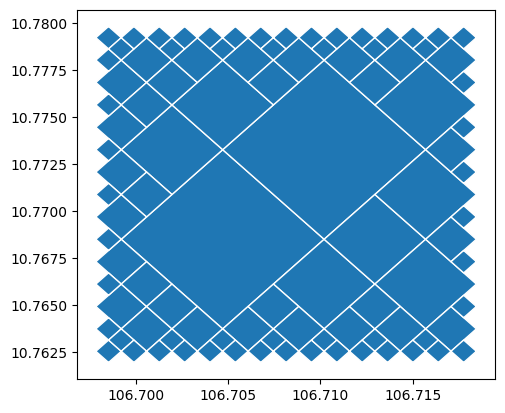

In [ ]:
from vgrid.generator.dggalgen import dggalgen

dggs_type = "healpix"  # choose one from ['gnosis','isea4r','isea9r','isea3h','isea7h','isea7h_z7',
# 'ivea4r','ivea9r','ivea3h','ivea7h','ivea7h_z7','rtea4r','rtea9r','rtea3h','rtea7h','rtea7h_z7','healpix','rhealpix']
resolution = 16
bbox = [
    106.699007,
    10.762811,
    106.717674,
    10.778649,
]  # (min_lon, min_lat, max_lon, max_lat)
dggal_grid = dggalgen(
    dggs_type=dggs_type,
    resolution=resolution,
    bbox=bbox,
    compact=True,
    split_antimeridian=False,
    output_format="gpd",
)
dggal_grid.plot(edgecolor="white")

### DGGAL Inspect

In [ ]:
from vgrid.stats.dggalstats import dggalinspect

dggs_type = "ivea4r"  # choose one from ['gnosis','isea4r','isea9r','isea3h','isea7h','isea7h_z7',
# 'ivea4r','ivea9r','ivea3h','ivea7h','ivea7h_z7','rtea4r','rtea9r','rtea3h','rtea7h','rtea7h_z7','healpix','rhealpix']
resolution = 5
dggal_inspect = dggalinspect(dggs_type, resolution)
dggal_inspect

Generating IVEA4R DGGS: 100%|██████████| 10240/10240 [00:18<00:00, 567.63it/s]


### DGGAL Normalized Area Histogram

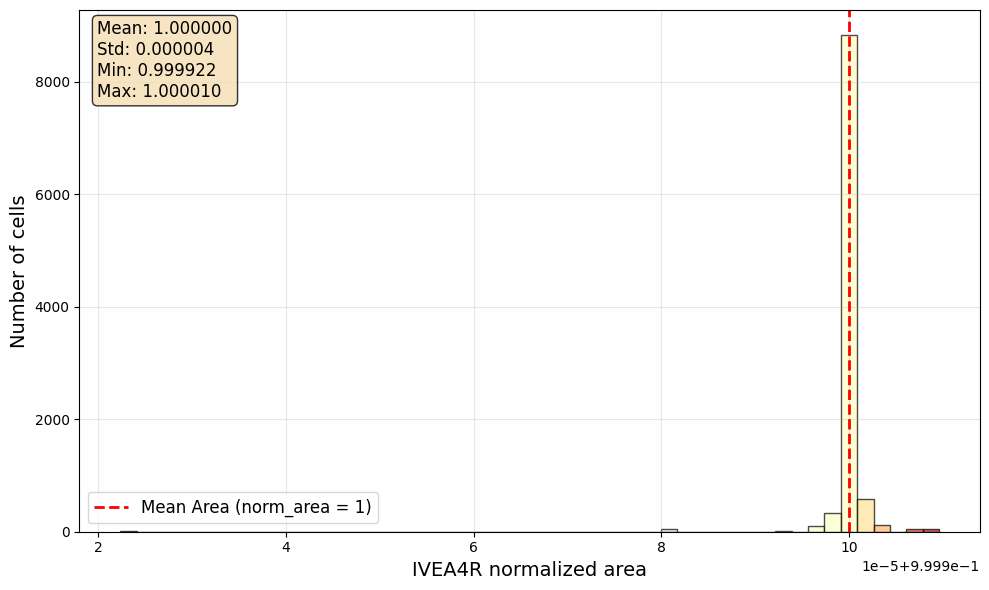

In [14]:
from vgrid.stats.dggalstats import dggal_norm_area_hist

dggal_norm_area_hist(dggs_type, dggal_inspect)

### Distribution of DGGAL Area Distortions

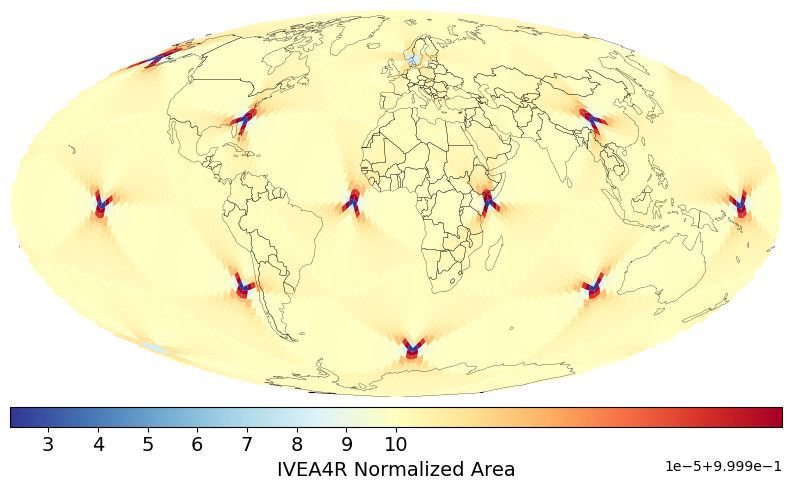

In [15]:
from vgrid.stats.dggalstats import dggal_norm_area

dggal_norm_area(dggs_type, dggal_inspect, crs="proj=moll")

### DGGAL IPQ Compactness Histogram

Isoperimetric Inequality (IPQ) Compactness (suggested by [Osserman, 1978](https://sites.math.washington.edu/~toro/Courses/20-21/MSF/osserman.pdf)):

$$C_{IPQ} = \frac{4 \pi A}{p^2}$$
The range of the IPQ compactness metric is [0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.


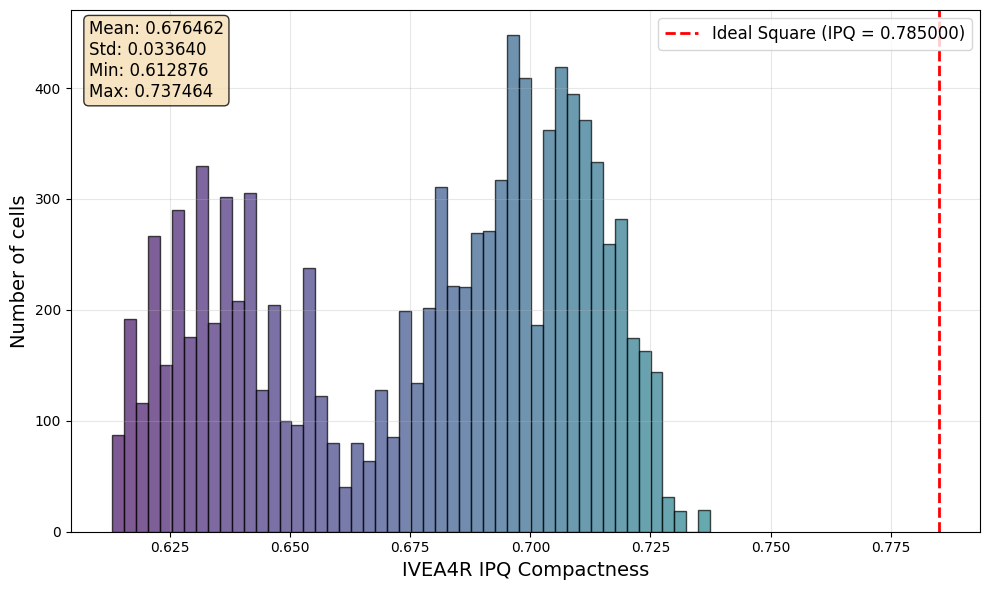

In [10]:
from vgrid.stats.dggalstats import dggal_compactness_ipq_hist

dggal_compactness_ipq_hist(dggs_type, dggal_inspect)

### Distribution of DGGAL IPQ Compactness

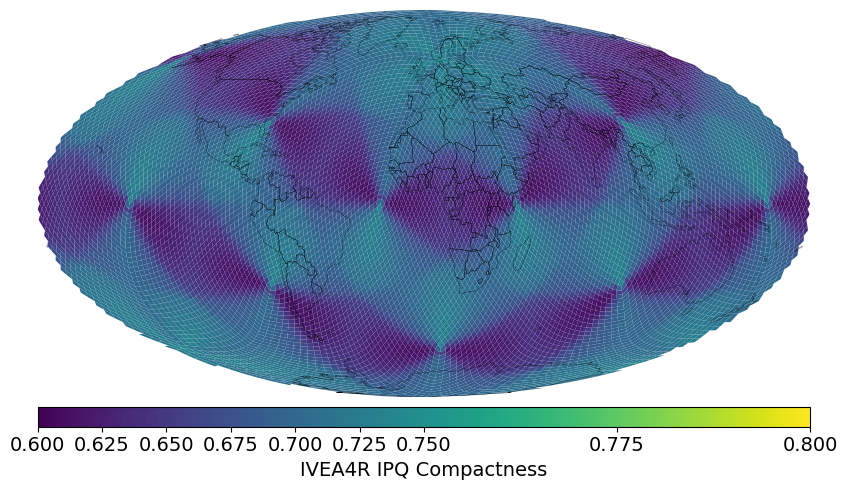

In [11]:
from vgrid.stats.dggalstats import dggal_compactness_ipq

dggal_compactness_ipq(dggs_type, dggal_inspect, crs="proj=moll")

DGGAL Convex hull Compactness Histogram:

$$C_{CVH} = \frac{A}{A_{CVH}}$$


The range of the Convex hull compactness metric is [0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.


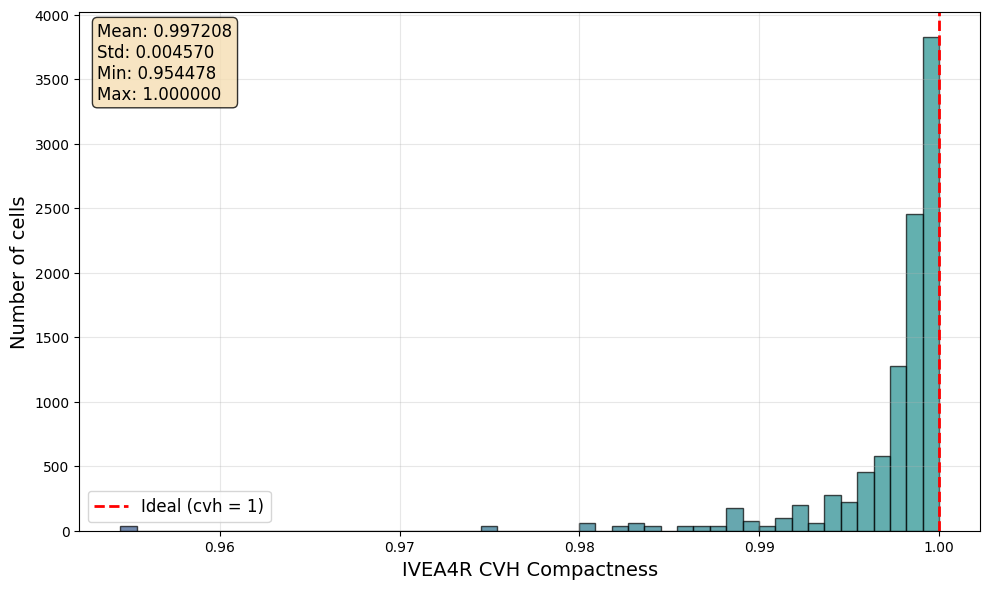

In [12]:
from vgrid.stats.dggalstats import dggal_compactness_cvh_hist

dggal_compactness_cvh_hist(dggs_type, dggal_inspect)

### Distribution of DGGAL Convex hull Compactness

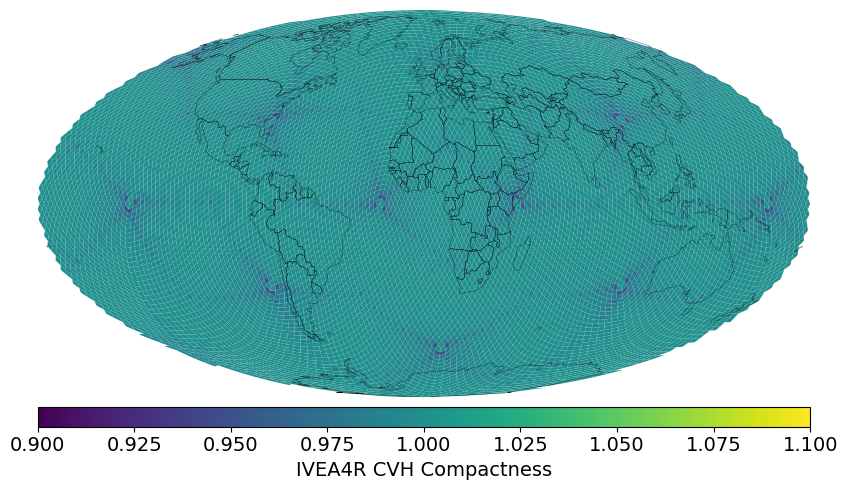

In [13]:
from vgrid.stats.dggalstats import dggal_compactness_cvh

dggal_compactness_cvh(dggs_type, dggal_inspect)

### DGGAL Statistics

Characteristic Length Scale (CLS - suggested by Ralph Kahn): the diameter of a spherical cap of the same cell's area

In [ ]:
from vgrid.stats.dggalstats import dggalstats

dggs_type = "rhealpix"  # choose one from ['gnosis','isea4r','isea9r','isea3h','isea7h','isea7h_z7',
# 'ivea4r','ivea9r','ivea3h','ivea7h','ivea7h_z7','rtea4r','rtea9r','rtea3h','rtea7h','rtea7h_z7','healpix','rhealpix']
dggal_stats = dggalstats(dggs_type, unit="m")
dggal_stats

,resolution,number_of_cells,avg_edge_len_m,avg_cell_area_m2,cls_m
0,0,8,7.984873e+06,6.375820e+13,9.209090e+06
1,1,24,4.610069e+06,2.125273e+13,5.238725e+06
2,2,88,2.407530e+06,5.796200e+12,2.721778e+06
3,3,344,1.217682e+06,1.482749e+12,1.374673e+06
4,4,1368,6.106185e+05,3.728550e+11,6.890932e+05
5,5,5464,3.055327e+05,9.335022e+10,3.447672e+05
6,6,21848,1.527943e+05,2.334610e+10,1.724112e+05
7,7,87384,7.640065e+04,5.837060e+09,8.620907e+04
8,8,349528,3.820076e+04,1.459298e+09,4.310497e+04
9,9,1398104,1.910044e+04,3.648267e+08,2.155254e+04
